In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import warnings
warnings.filterwarnings('ignore')

# Cargar dataset y modelo
daily = pd.read_csv("../data/processed/eurusd_con_sentimiento.csv",
                    index_col=0, parse_dates=True)

with open("../data/processed/fusion_model.pkl", "rb") as f:
    modelo_fusion = pickle.load(f)

print(f"Dataset: {daily.shape}")
print(f"Modelo cargado: XGBoost Fusion Layer")
print(f"Período: {daily.index[0].date()} → {daily.index[-1].date()}")

Dataset: (4031, 40)
Modelo cargado: XGBoost Fusion Layer
Período: 2010-10-08 → 2026-04-03


In [4]:
# Features del modelo fusion
features_fusion = [
    'momentum_5', 'momentum_10', 'momentum_20',
    'return_lag_1', 'return_lag_2', 'return_lag_3',
    'regime', 'sentiment_score', 'sentiment_uncertainty',
    'volatility_20', 'rsi_14', 'atr_14',
    'bb_width', 'bb_position',
    'macd', 'macd_hist',
    'trend_20_50', 'trend_50_200'
]

# Preparar datos
data = daily[features_fusion + ['Close', 'returns']].dropna()

# Generar señales en todo el período
X = data[features_fusion]
data['signal'] = modelo_fusion.predict(X)
data['signal_prob'] = modelo_fusion.predict_proba(X)[:, 1]

# Solo operar cuando la convicción supera 55%
data['position'] = 0
data.loc[data['signal_prob'] > 0.55, 'position'] = 1   # Long
data.loc[data['signal_prob'] < 0.45, 'position'] = -1  # Short

print("Señales generadas:")
print(data['position'].value_counts())
print(f"\nConvicción promedio: {data['signal_prob'].mean():.4f}")

Señales generadas:
position
-1    1651
 1    1394
 0     986
Name: count, dtype: int64

Convicción promedio: 0.4853


In [5]:
# Calcular retornos de la estrategia
data['strategy_returns'] = data['position'].shift(1) * data['returns']
data['buyhold_returns'] = data['returns']

# Acumular retornos
data['strategy_cum'] = (1 + data['strategy_returns']).cumprod()
data['buyhold_cum'] = (1 + data['buyhold_returns']).cumprod()

# Métricas de rendimiento
def calcular_metricas(retornos, nombre):
    retornos = retornos.dropna()
    
    # Retorno anualizado
    n_years = len(retornos) / 252
    retorno_total = (1 + retornos).prod() - 1
    retorno_anual = (1 + retorno_total) ** (1/n_years) - 1
    
    # Sharpe ratio
    sharpe = retornos.mean() / retornos.std() * np.sqrt(252)
    
    # Max drawdown
    cum = (1 + retornos).cumprod()
    rolling_max = cum.cummax()
    drawdown = (cum - rolling_max) / rolling_max
    max_dd = drawdown.min()
    
    # Win rate
    win_rate = (retornos > 0).sum() / len(retornos)
    
    print(f"\n{'='*40}")
    print(f"  {nombre}")
    print(f"{'='*40}")
    print(f"  Retorno total:    {retorno_total*100:.1f}%")
    print(f"  Retorno anual:    {retorno_anual*100:.1f}%")
    print(f"  Sharpe ratio:     {sharpe:.3f}")
    print(f"  Max drawdown:     {max_dd*100:.1f}%")
    print(f"  Win rate:         {win_rate*100:.1f}%")
    
    return sharpe

sharpe_strategy = calcular_metricas(data['strategy_returns'], "KRONOS")
sharpe_bh = calcular_metricas(data['buyhold_returns'], "Buy & Hold")


  KRONOS
  Retorno total:    8287.0%
  Retorno anual:    31.9%
  Sharpe ratio:     3.921
  Max drawdown:     -5.0%
  Win rate:         45.9%

  Buy & Hold
  Retorno total:    -21.6%
  Retorno anual:    -1.5%
  Sharpe ratio:     -0.142
  Max drawdown:     -38.0%
  Win rate:         49.2%


In [6]:
# Walk-forward validation CORRECTO
# Entrenamos en el pasado, evaluamos en el futuro — nunca al revés

from sklearn.metrics import accuracy_score
import xgboost as xgb

resultados_wf = []
window_train = 756   # 3 años de entrenamiento
window_test = 63     # 3 meses de test

data_wf = daily[features_fusion + ['Close', 'returns']].dropna()
data_wf['target'] = (data_wf['Close'].shift(-5) > data_wf['Close']).astype(int)
data_wf = data_wf.dropna()

X_wf = data_wf[features_fusion]
y_wf = data_wf['target']

n_splits = (len(data_wf) - window_train) // window_test
print(f"Total splits: {n_splits}")
print(f"Evaluando {n_splits * window_test} días fuera de muestra...")

for i in range(n_splits):
    start_train = i * window_test
    end_train = start_train + window_train
    end_test = end_train + window_test
    
    if end_test > len(data_wf):
        break
    
    X_tr = X_wf.iloc[start_train:end_train]
    y_tr = y_wf.iloc[start_train:end_train]
    X_te = X_wf.iloc[end_train:end_test]
    y_te = y_wf.iloc[end_train:end_test]
    
    modelo_wf = xgb.XGBClassifier(
        n_estimators=200, max_depth=4,
        learning_rate=0.05, subsample=0.8,
        random_state=42, verbosity=0
    )
    modelo_wf.fit(X_tr, y_tr)
    
    y_pred = modelo_wf.predict(X_te)
    prob = modelo_wf.predict_proba(X_te)[:, 1]
    acc = accuracy_score(y_te, y_pred)
    
    # Retornos del período
    rets = data_wf['returns'].iloc[end_train:end_test]
    position = np.where(prob > 0.55, 1, np.where(prob < 0.45, -1, 0))
    strat_rets = pd.Series(position, index=rets.index).shift(1) * rets
    sharpe_periodo = strat_rets.mean() / strat_rets.std() * np.sqrt(252) if strat_rets.std() > 0 else 0
    
    resultados_wf.append({
        'periodo': i+1,
        'fecha_inicio': data_wf.index[end_train].date(),
        'accuracy': acc,
        'sharpe': sharpe_periodo
    })

df_wf = pd.DataFrame(resultados_wf)
print(f"\nResultados Walk-Forward:")
print(df_wf.to_string(index=False))
print(f"\nAccuracy promedio: {df_wf['accuracy'].mean():.4f}")
print(f"Sharpe promedio:   {df_wf['sharpe'].mean():.3f}")

Total splits: 51
Evaluando 3213 días fuera de muestra...

Resultados Walk-Forward:
 periodo fecha_inicio  accuracy    sharpe
       1   2013-09-03  0.523810 -1.160157
       2   2013-12-02  0.603175  0.687712
       3   2014-02-27  0.412698  2.294021
       4   2014-05-27  0.380952 -2.590203
       5   2014-08-22  0.666667  1.934257
       6   2014-11-19  0.396825 -1.363894
       7   2015-02-16  0.682540  4.463956
       8   2015-05-14  0.412698 -1.551683
       9   2015-08-11  0.301587 -2.507441
      10   2015-11-06  0.507937  0.999421
      11   2016-02-03  0.666667  1.449084
      12   2016-05-02  0.539683 -0.202440
      13   2016-07-28  0.396825 -0.662872
      14   2016-10-25  0.460317 -1.059172
      15   2017-01-20  0.523810  1.413381
      16   2017-04-19  0.365079 -3.059773
      17   2017-07-18  0.555556 -0.462146
      18   2017-10-13  0.571429  1.605061
      19   2018-01-11  0.523810  2.858073
      20   2018-04-10  0.349206 -2.778815
      21   2018-07-06  0.507937  1.

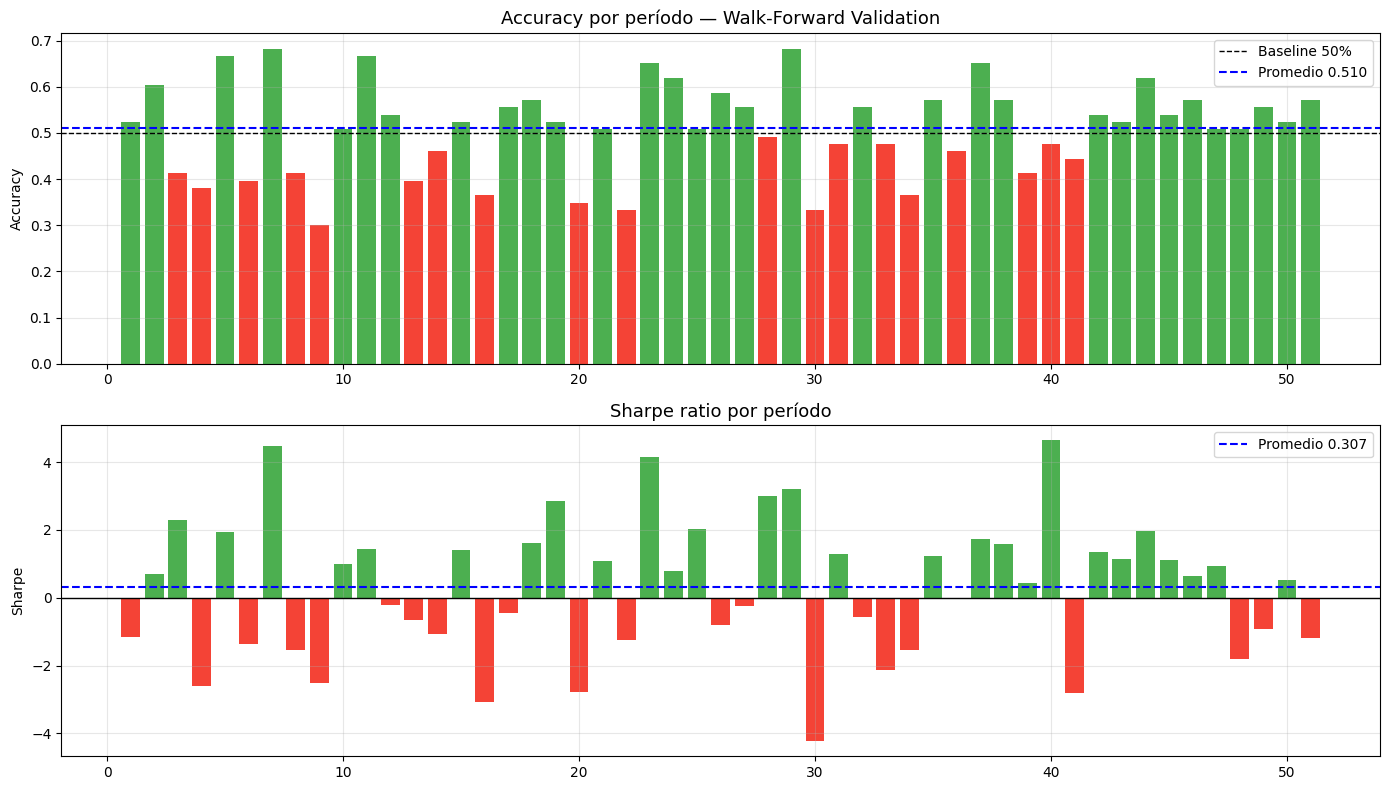


Períodos con Sharpe > 1.0: 21/51
Períodos con Sharpe > 0.0: 28/51


In [7]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Accuracy por período
axes[0].bar(df_wf['periodo'], df_wf['accuracy'], 
            color=['#4CAF50' if x > 0.5 else '#F44336' for x in df_wf['accuracy']])
axes[0].axhline(0.5, color='black', linewidth=1, linestyle='--', label='Baseline 50%')
axes[0].axhline(df_wf['accuracy'].mean(), color='blue', linewidth=1.5, 
                linestyle='--', label=f"Promedio {df_wf['accuracy'].mean():.3f}")
axes[0].set_title('Accuracy por período — Walk-Forward Validation', fontsize=13)
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Sharpe por período
axes[1].bar(df_wf['periodo'], df_wf['sharpe'],
            color=['#4CAF50' if x > 0 else '#F44336' for x in df_wf['sharpe']])
axes[1].axhline(0, color='black', linewidth=1)
axes[1].axhline(df_wf['sharpe'].mean(), color='blue', linewidth=1.5,
                linestyle='--', label=f"Promedio {df_wf['sharpe'].mean():.3f}")
axes[1].set_title('Sharpe ratio por período', fontsize=13)
axes[1].set_ylabel('Sharpe')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/processed/09_walkforward.png', dpi=150)
plt.show()
print(f"\nPeríodos con Sharpe > 1.0: {(df_wf['sharpe'] > 1.0).sum()}/{len(df_wf)}")
print(f"Períodos con Sharpe > 0.0: {(df_wf['sharpe'] > 0.0).sum()}/{len(df_wf)}")